In [1]:
import pandas as pd
df = pd.read_csv("covid_19_clean_complete.csv")
print(df.to_string())

                     Province/State                    Country/Region        Lat        Long        Date  Confirmed  Deaths  Recovered   Active             WHO Region
0                               NaN                       Afghanistan  33.939110   67.709953  2020-01-22          0       0          0        0  Eastern Mediterranean
1                               NaN                           Albania  41.153300   20.168300  2020-01-22          0       0          0        0                 Europe
2                               NaN                           Algeria  28.033900    1.659600  2020-01-22          0       0          0        0                 Africa
3                               NaN                           Andorra  42.506300    1.521800  2020-01-22          0       0          0        0                 Europe
4                               NaN                            Angola -11.202700   17.873900  2020-01-22          0       0          0        0                 Afric

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [3]:
df.isnull().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Date                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [4]:
df.shape

(49068, 10)

In [5]:
df.drop("Province/State",axis=1)

,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...
49063,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [9]:
country_cases = df.groupby("Country/Region")[["Confirmed", "Deaths", "Recovered"]].max()
country_cases.sort_values("Confirmed",ascending=False).head()

,Confirmed,Deaths,Recovered
Country/Region,,,
US,4290259,148011,1325804
Brazil,2442375,87618,1846641
India,1480073,33408,951166
Russia,816680,13334,602249
South Africa,452529,7067,274925


In [14]:
country_cases["Recovery Rate"] = (country_cases["Recovered"]/country_cases["Confirmed"])*100
country_cases["Deaths Rate"] = (country_cases["Deaths"]/country_cases["Confirmed"])*100
print(country_cases["Recovery Rate"])
print(country_cases["Deaths Rate"])

Country/Region
Afghanistan           69.486805
Albania               56.250000
Algeria               67.339935
Andorra               88.533627
Angola                25.473684
                        ...    
West Bank and Gaza    35.326240
Western Sahara        80.000000
Yemen                 49.260792
Zambia                61.840949
Zimbabwe              20.044379
Name: Recovery Rate, Length: 187, dtype: float64
Country/Region
Afghanistan            3.499435
Albania                2.950820
Algeria                4.157581
Andorra                5.733186
Angola                 4.315789
                        ...    
West Bank and Gaza     0.734394
Western Sahara        10.000000
Yemen                 28.562980
Zambia                 3.075571
Zimbabwe               1.331361
Name: Deaths Rate, Length: 187, dtype: float64


In [16]:
daily_cases = df.groupby("Date")["Confirmed"].sum().reset_index()

daily_cases["New Cases"] = daily_cases["Confirmed"].diff()
print(daily_cases)
print(daily_cases)


           Date  Confirmed  New Cases
0    2020-01-22        555        NaN
1    2020-01-23        654       99.0
2    2020-01-24        941      287.0
3    2020-01-25       1434      493.0
4    2020-01-26       2118      684.0
..          ...        ...        ...
183  2020-07-23   15510481   282756.0
184  2020-07-24   15791645   281164.0
185  2020-07-25   16047190   255545.0
186  2020-07-26   16251796   204606.0
187  2020-07-27   16480485   228689.0

[188 rows x 3 columns]
           Date  Confirmed  New Cases
0    2020-01-22        555        NaN
1    2020-01-23        654       99.0
2    2020-01-24        941      287.0
3    2020-01-25       1434      493.0
4    2020-01-26       2118      684.0
..          ...        ...        ...
183  2020-07-23   15510481   282756.0
184  2020-07-24   15791645   281164.0
185  2020-07-25   16047190   255545.0
186  2020-07-26   16251796   204606.0
187  2020-07-27   16480485   228689.0

[188 rows x 3 columns]


In [17]:
top_countries = (country_cases.sort_values("Confirmed", ascending=False).head(10))

print(top_countries)

                Confirmed  Deaths  Recovered  Recovery Rate  Deaths Rate
Country/Region                                                          
US                4290259  148011    1325804      30.902656     3.449932
Brazil            2442375   87618    1846641      75.608414     3.587410
India             1480073   33408     951166      64.264803     2.257186
Russia             816680   13334     602249      73.743572     1.632708
South Africa       452529    7067     274925      60.753013     1.561668
Mexico             395489   44022     303810      76.818824    11.131030
Peru               389717   18418     272547      69.934594     4.725993
Chile              347923    9187     319954      91.961152     2.640527
United Kingdom     300111   45759        533       0.177601    15.247358
Iran               293606   15912     255144      86.900131     5.419508


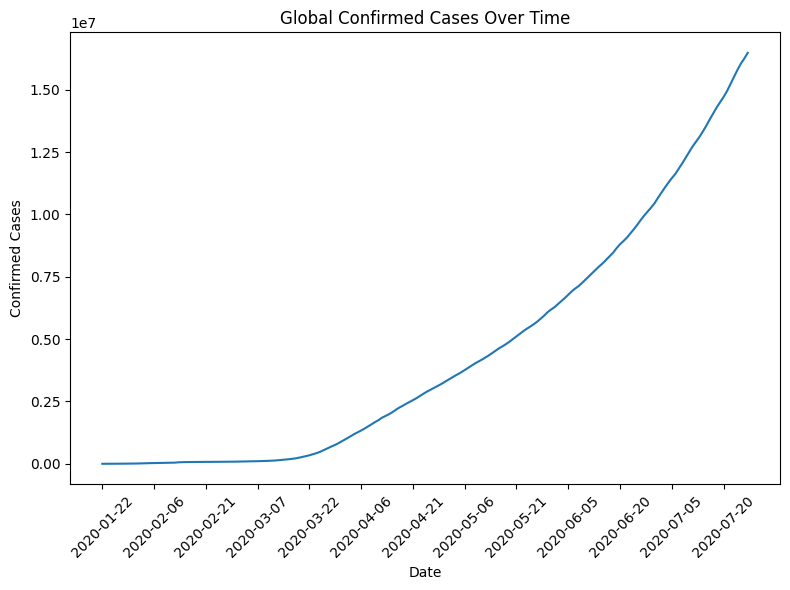

In [21]:
import matplotlib.pyplot as plt

daily_cases = df.groupby("Date")["Confirmed"].sum()

plt.figure(figsize=(8,6))
plt.plot(daily_cases)

plt.title("Global Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")

# Show only every 15th date
plt.xticks(daily_cases.index[::15], rotation=45)

plt.tight_layout()
plt.show()